In [1]:
import re

def get_train_info_from_file(filename):
    step_num, loss, pplx, bpc, lr = [], [], [], [], []

    pattern = r"\[(?P<step>\d+)\] .*?gnorm (?P<gnorm>[\d.]+) lr (?P<lr>[\d.]+) \| loss (?P<loss>[\d.]+) \| pplx\s+(?P<pplx>[\d.]+), bpc\s+(?P<bpc>[\d.]+)"

    with open(filename, 'r') as f:
        for line in f:
            if '| loss' in line:
                match = re.search(pattern, line)
                metrics = match.groupdict()
                # print(metrics)
                step_num.append(int(metrics['step']))
                loss.append(float(metrics['loss']))
                pplx.append(float(metrics['pplx']))
                bpc.append(float(metrics['bpc']))
                lr.append(float(metrics['lr']))

    return step_num, loss, pplx, bpc, lr


[8.11, 6.85, 6.54, 6.31, 6.15, 6.04, 5.96, 5.91, 5.81, 5.74, 5.65, 5.57, 5.53, 5.53, 5.48, 5.46, 5.4, 5.25, 5.32, 5.29, 5.27, 5.2, 5.21, 5.14, 5.16, 5.11, 5.09, 5.05, 5.07, 5.03, 5.01, 4.97, 5.0, 4.92, 5.0, 4.92, 4.87, 4.89, 4.91, 4.93, 4.86, 4.84, 4.83, 4.8, 4.8, 4.8, 4.74, 4.8, 4.75, 4.73, 4.73, 4.72, 4.75, 4.66, 4.66, 4.65, 4.61, 4.64, 4.72, 4.64, 4.61, 4.55, 4.65, 4.61, 4.6, 4.56, 4.55, 4.58, 4.49, 4.52, 4.52, 4.49, 4.57, 4.57, 4.53, 4.52, 4.49, 4.51, 4.51, 4.52, 4.45, 4.46, 4.46, 4.47, 4.44, 4.47, 4.43, 4.43, 4.41, 4.49, 4.42, 4.36, 4.35, 4.39, 4.39, 4.36, 4.42, 4.38, 4.42, 4.4, 4.3, 4.36, 4.4, 4.33, 4.29, 4.3, 4.34, 4.24, 4.3, 4.34, 4.32, 4.31, 4.38, 4.26, 4.32, 4.29, 4.28, 4.26, 4.27, 4.26, 4.27, 4.27, 4.19, 4.23, 4.31, 4.31, 4.29, 4.21, 4.27, 4.18, 4.2, 4.19, 4.21, 4.19, 4.22, 4.21, 4.2, 4.21, 4.21, 4.2, 4.15, 4.18, 4.09, 4.21, 4.12, 4.13, 4.17, 4.18, 4.15, 4.15, 4.09, 4.13, 4.17, 4.18, 4.18, 4.1, 4.17, 4.16, 4.13, 4.15, 4.13, 4.15, 4.09, 4.12, 4.14, 4.11, 4.14, 4.13, 4.11, 4.0

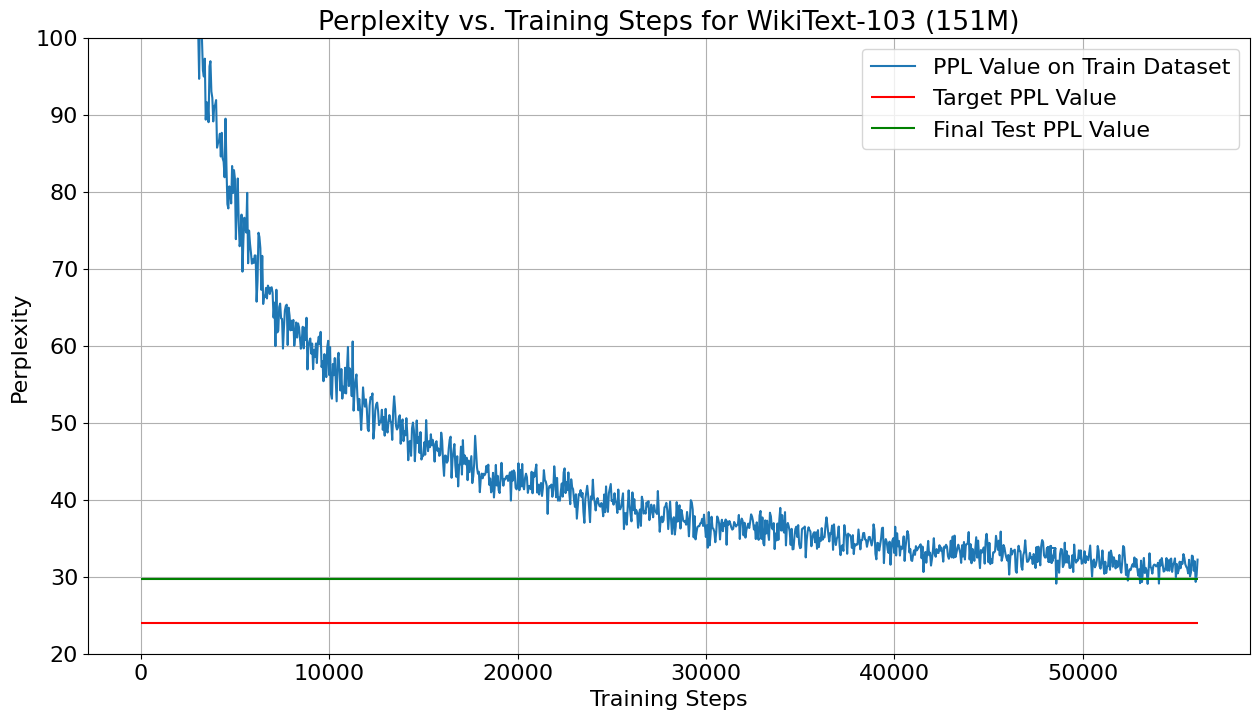

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

step_num, loss, pplx, bpc, lr = get_train_info_from_file('wikitext_103_train.txt')
print(loss)
plt.plot(step_num, pplx, label='PPL Value on Train Dataset')
# plt.plot(step_num, bpc)
plt.grid()
plt.gcf().set_size_inches(15, 8)
plt.ylim(20, 100)
plt.hlines(24.0, xmin=0, xmax=step_num[-1], color='red', label='Target PPL Value')
plt.hlines(29.70, xmin=0, xmax=step_num[-1], color='green', label='Final Test PPL Value')
plt.title('Perplexity vs. Training Steps for WikiText-103 (151M)')
plt.legend()
plt.ylabel('Perplexity')
plt.xlabel('Training Steps')
plt.savefig('img/wt-103.svg')


[4.5417, 3.8791, 3.4688, 3.0355, 2.7657, 2.5266, 2.4368, 2.4178, 2.3579, 2.3288, 2.2418, 2.1579, 2.0747, 2.0238, 1.9257, 2.0001, 1.9403, 1.8887, 1.8804, 1.8458, 1.8511, 1.8081, 1.8198, 1.7258, 1.7184, 1.7465, 1.7748, 1.7009, 1.742, 1.7261, 1.658, 1.7288, 1.6865, 1.6507, 1.6984, 1.638, 1.6533, 1.7018, 1.72, 1.6877, 1.6882, 1.6094, 1.6265, 1.6423, 1.6241, 1.642, 1.6181, 1.5936, 1.6305, 1.6015, 1.6394, 1.6242, 1.604, 1.5593, 1.5729, 1.6079, 1.6169, 1.5596, 1.5597, 1.5513, 1.542, 1.5986, 1.5704, 1.5578, 1.5299, 1.4935, 1.5814, 1.5572, 1.5513, 1.5414, 1.5479, 1.5303, 1.5379, 1.5378, 1.4878, 1.5174, 1.5202, 1.542, 1.5449, 1.537, 1.5124, 1.5121, 1.5556, 1.5508, 1.4977, 1.4948, 1.4736, 1.5122, 1.5231, 1.549, 1.5228, 1.5182, 1.5199, 1.4793, 1.4537, 1.4759, 1.5052, 1.4679, 1.4633, 1.4877, 1.5126, 1.5244, 1.5041, 1.4946, 1.4713, 1.5122, 1.5151, 1.5293, 1.5001, 1.4973, 1.4883, 1.4838, 1.466, 1.458, 1.4537, 1.4289, 1.4336, 1.4445, 1.478, 1.4515, 1.4768, 1.484, 1.5174, 1.4424, 1.4546, 1.4893, 1.4698

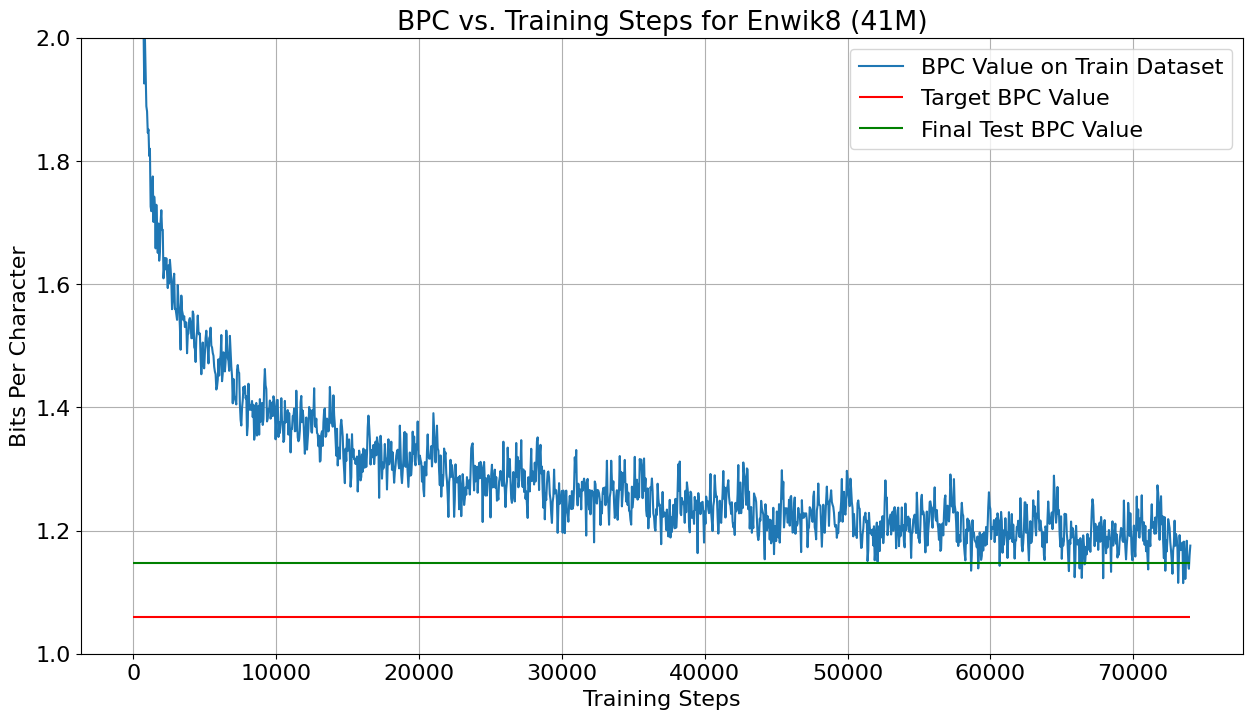

In [6]:
step_num, loss, pplx, bpc, lr = get_train_info_from_file('enwik8_train.txt')
print(bpc)
plt.plot(step_num, bpc, label='BPC Value on Train Dataset')
# plt.plot(step_num, bpc)
plt.grid()
plt.gcf().set_size_inches(15, 8)
plt.ylim(1,2)
# plt.ylim(0.75,1.6)
plt.hlines(1.06, xmin=0, xmax=step_num[-1], color='red', label='Target BPC Value')
plt.hlines(1.1476, xmin=0, xmax=step_num[-1], color='green', label='Final Test BPC Value')
plt.title('BPC vs. Training Steps for Enwik8 (41M)')
plt.legend()
plt.ylabel('Bits Per Character')
plt.xlabel('Training Steps')
plt.savefig('img/enwik8.svg')
